In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
 #Moderne, aber wissenschaftlich saubere Einstellungen
plt.rcParams.update({
    # Moderne, saubere Schrift (ohne Schnörkel)
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    # Ticks zeigen nach außen und nur unten/links 
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    # Dezentes Gitter
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":",     
    "grid.alpha": 0.5,
    
    # Legende ohne Rahmen
    "legend.frameon": True,
    
    # Hohe Auflösung
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

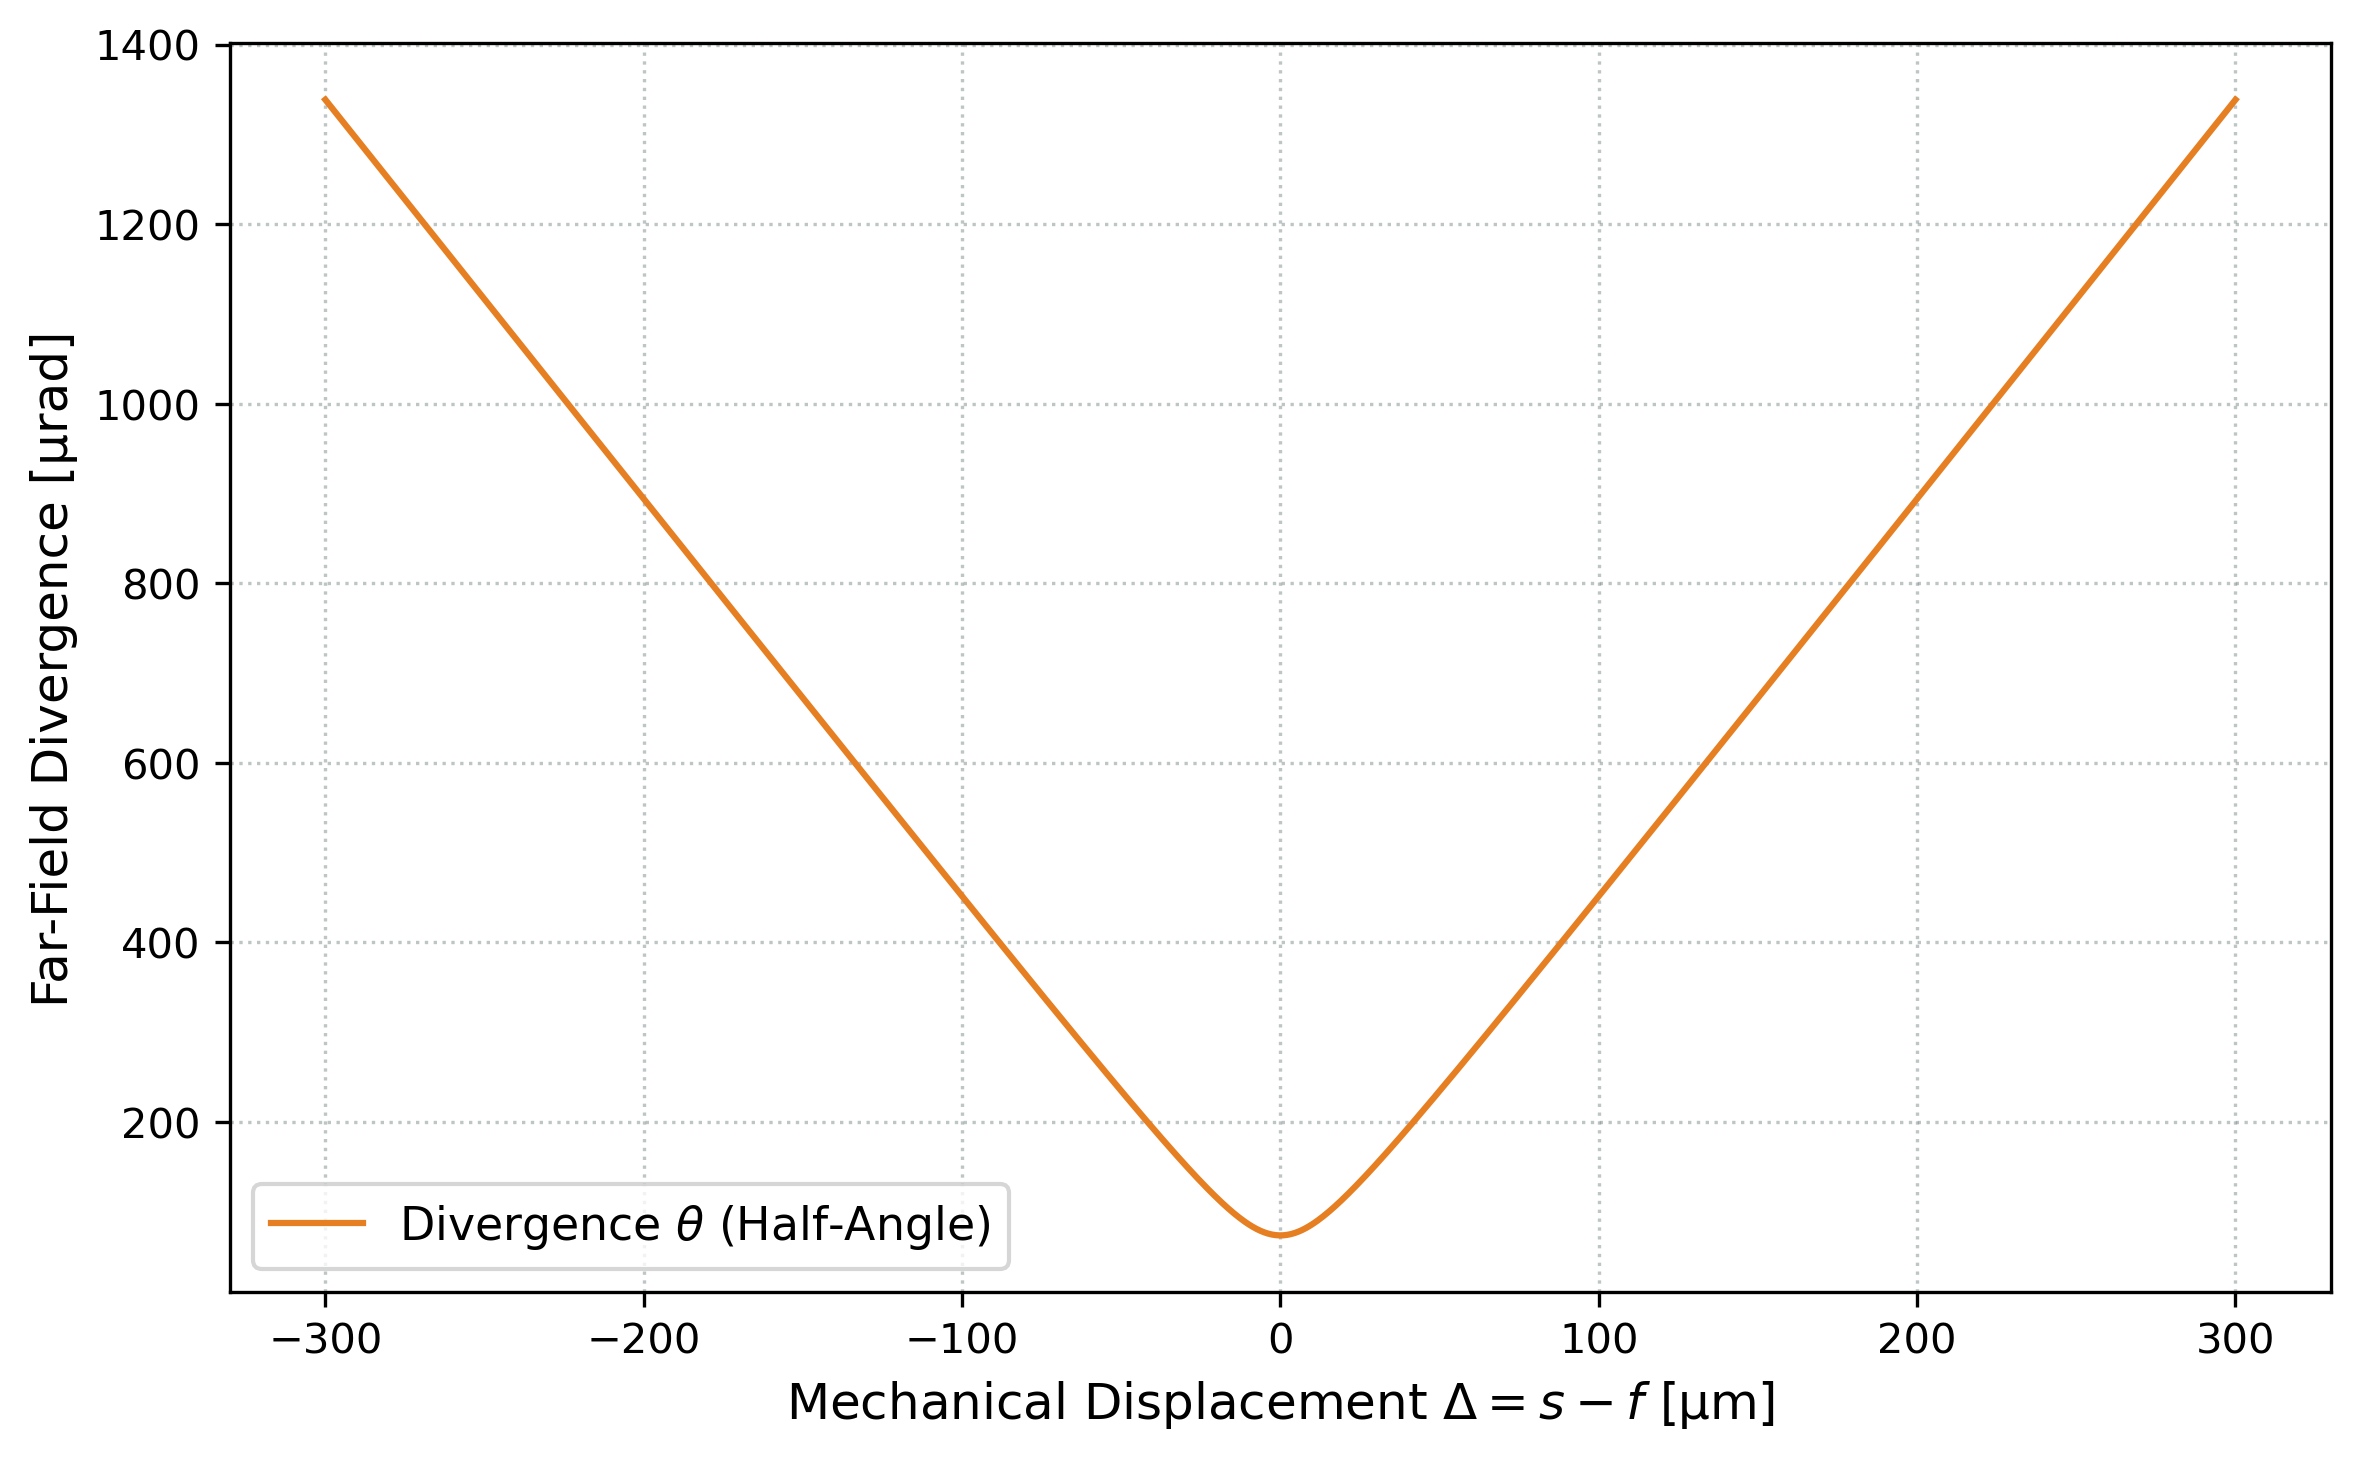

In [3]:
# ==========================================
# 1. System Parameters
# ==========================================
lam  = 1064e-9   # Wavelength [m]
M2   = 1.3       # Beam quality factor
MFD  = 5.4e-6    # Mode Field Diameter [m]
wf   = MFD / 2   # Waist radius at the fiber end [m]
f    = 36.6e-3   # Focal length [m]

lam_eff = M2 * lam  

# Mechanical displacement around the perfect focus (Delta)
delta = np.linspace(-300e-6, 300e-6, 1000)
zR = np.pi * wf**2 / lam_eff 

# ==========================================
# 2. Divergence Calculation
# ==========================================
def calculate_divergence(delta_val, focal_length, waist, wavelength_eff, rayleigh_range):
    # 1. Calculate the pre-factor
    term1 = wavelength_eff / (np.pi * focal_length * waist)
    
    # 2. Insert Delta directly 
    theta = np.sqrt(delta_val**2 + rayleigh_range**2) * term1
    return theta

# Perform calculation
theta_angle = calculate_divergence(delta, f, wf, lam_eff, zR)

# ==========================================
# 3. Plotting
# ==========================================
# 6.2 x 4 inches is ideal for a half-page LaTeX plot (without title)
plt.figure(figsize=(8, 5))

# Plotting the theoretical divergence
plt.plot(delta * 1e6, theta_angle * 1e6, color='#E67E22', label=r'Divergence $\theta$ (Half-Angle)')

# Marker for the physical minimum (perfect collimation)
#plt.axvline(0, color='#C8102E', linestyle='--', linewidth=1.5, alpha=0.7, label='Perfect Focus ($\Delta = 0$)')
#plt.plot(0, np.min(theta_angle) * 1e6, marker='o', markersize=6, color='#C8102E')

# Axis labels (Note: * 1e6 means we are in µm and µrad!)
plt.xlabel(r"Mechanical Displacement $\Delta = s - f$ [µm]")
plt.ylabel(r"Far-Field Divergence [µrad]")

# Title commented out for LaTeX!
# plt.title('Theoretical Divergence vs. Mechanical Displacement')

plt.legend()#loc='upper center'
plt.tight_layout()

# Save as vector graphic for LaTeX
plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/calculations_for_prototype/range_distance/divergence_displacement.pdf")

plt.show()

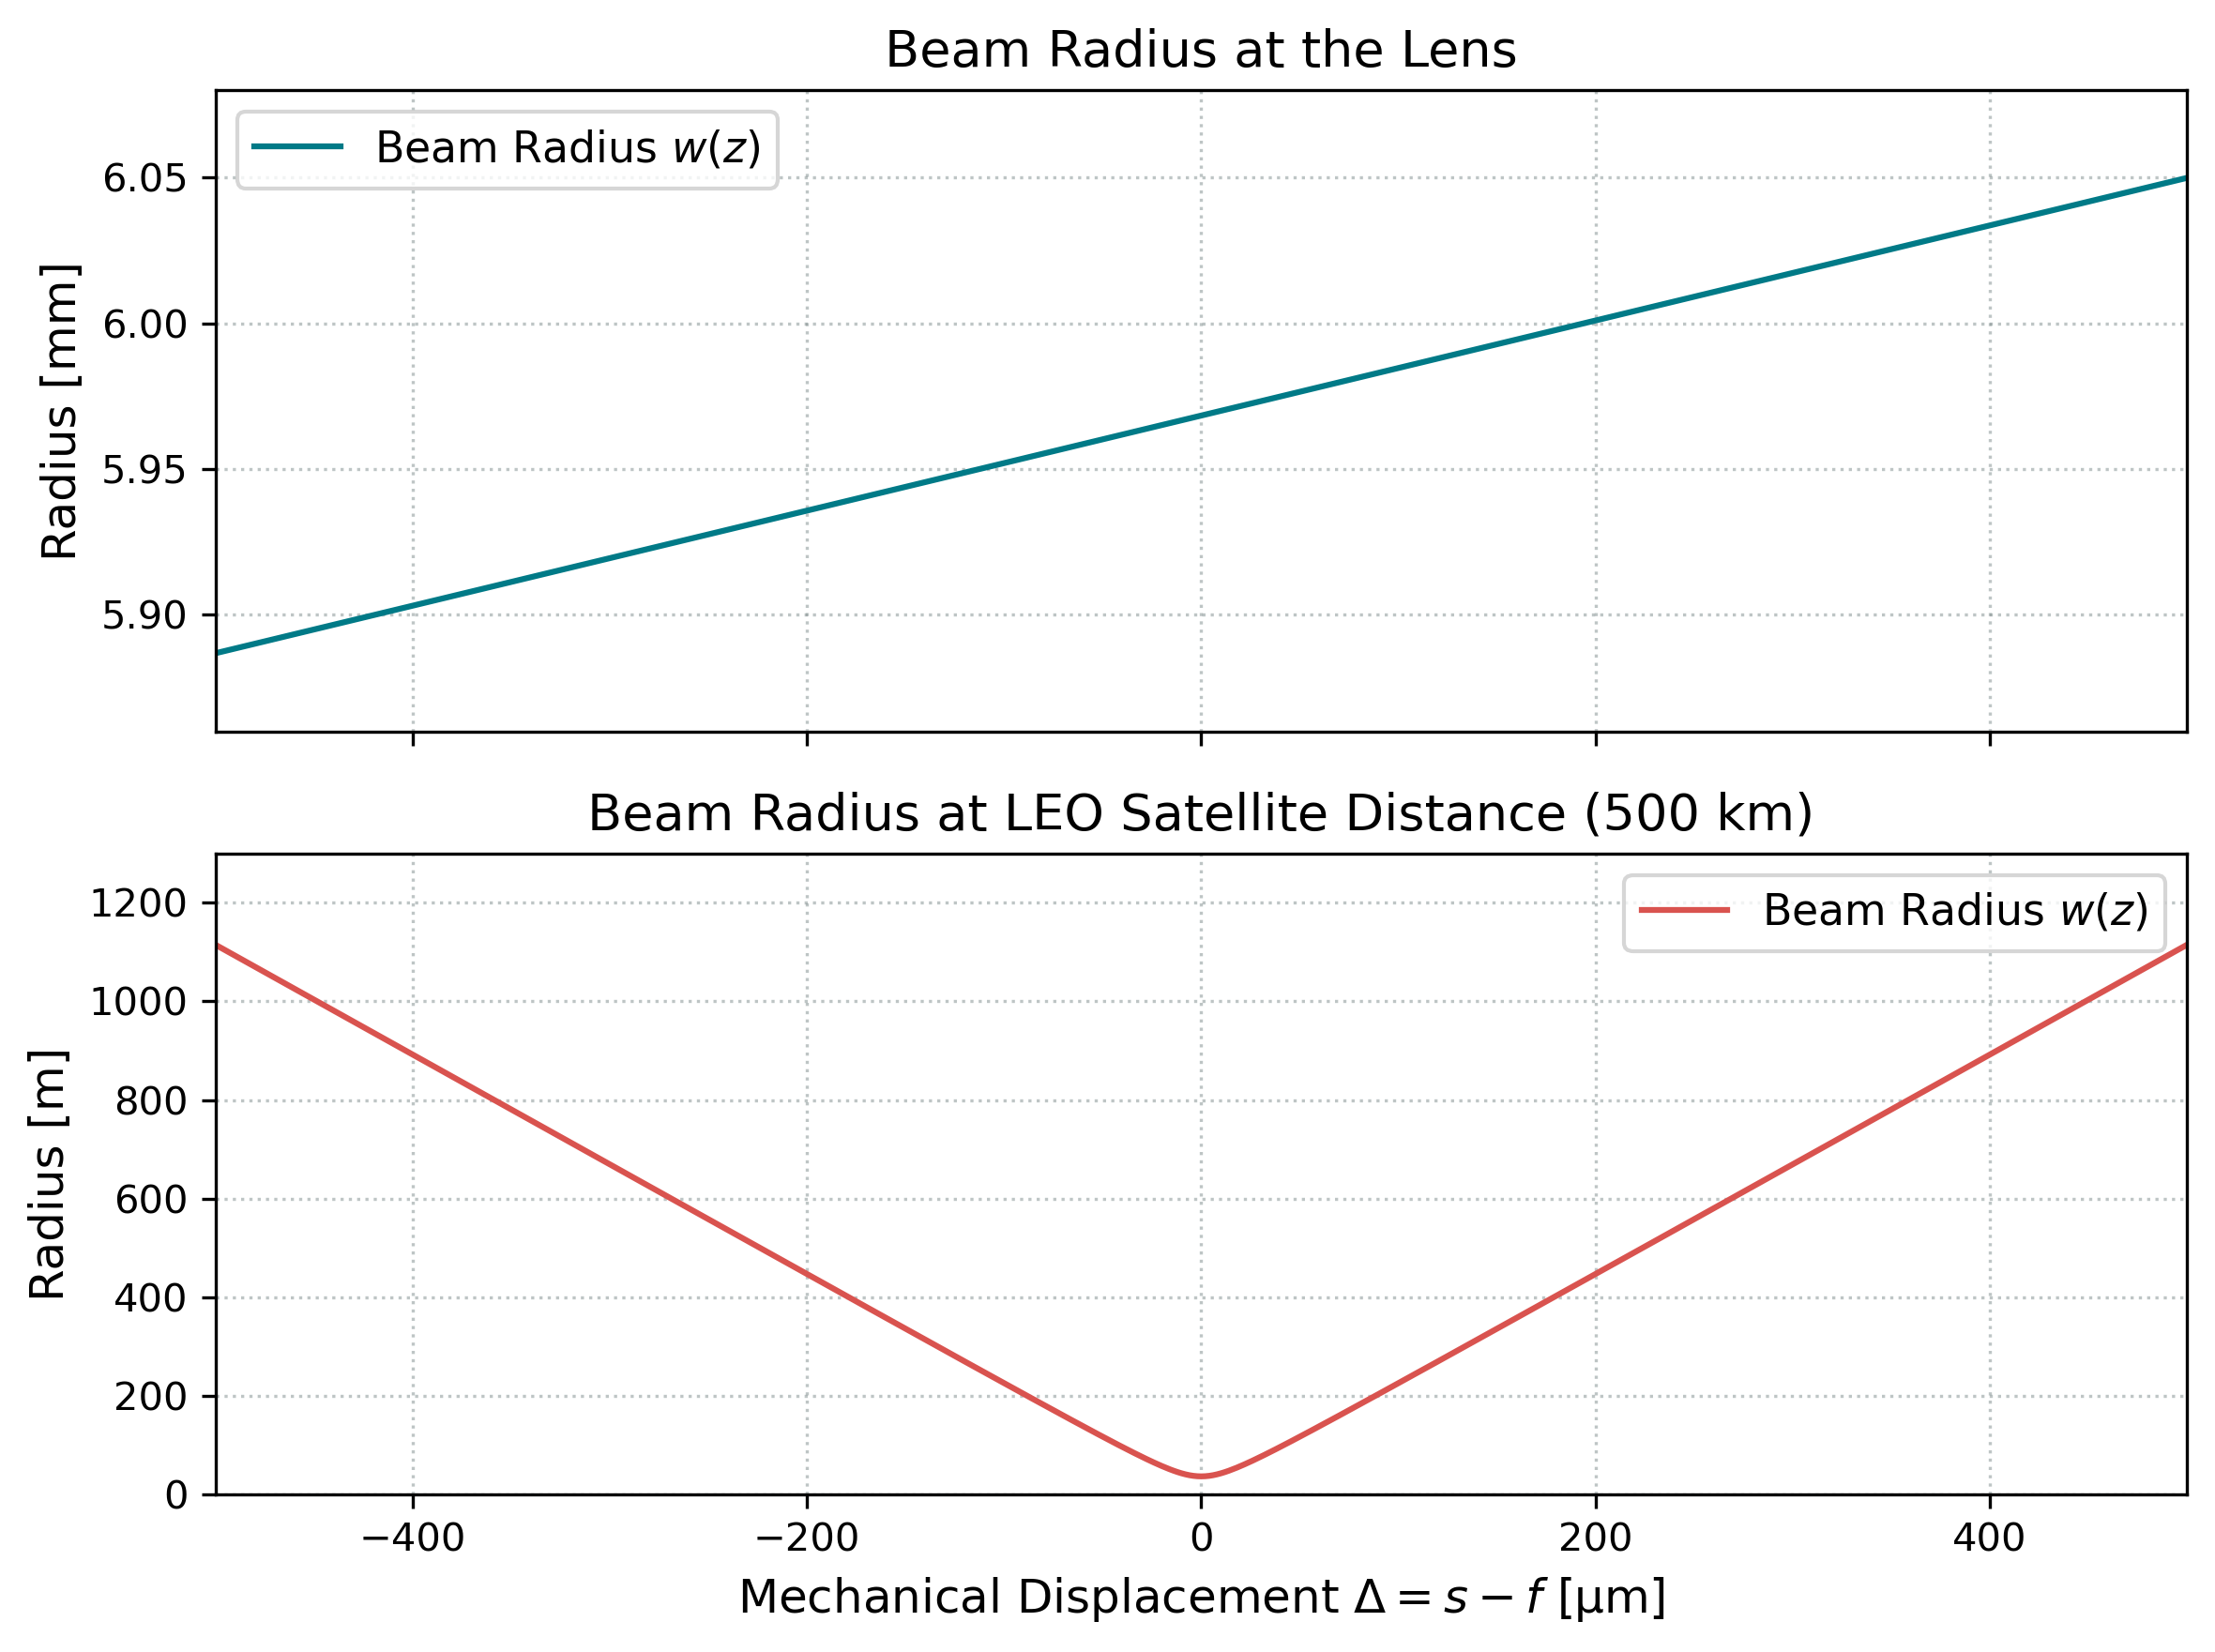

In [4]:
# ==========================================
# 1. System Parameters
# ==========================================
lam = 1064e-9      # Wavelength [m]
f = 36.6e-3        # Focal length of collimator [m]
M2 = 1.3           # Beam quality factor
MFD = 5.4e-6       # Mode Field Diameter of the fiber [m]
w0 = MFD / 2       # Beam waist radius at the fiber [m]

delta = np.linspace(-1e-3, 1e-3, 1001) # Mechanical displacement [m]
s = f + delta      # Object distance (fiber to lens) [m]

# ==========================================
# 2. Optical Calculations (Gaussian Beam)
# ==========================================
lam_eff = lam * M2                      
zR = (np.pi * w0**2) / lam_eff          

# Beam size at the lens
w_lens = w0 * np.sqrt(1 + (s / zR)**2)  

# q-parameter transformation
q1 = s + 1j * zR
q2 = 1 / (1 / q1 - 1 / f)

# New waist after the lens
z_waist = -np.real(q2)                  
zR_neu = np.imag(q2)                    
w0_new = np.sqrt(zR_neu * lam_eff / np.pi) 

# Beam size at 500 km
z2 = 500e3                              
w_500km = w0_new * np.sqrt(1 + ((z2 - z_waist) / zR_neu)**2)

# ==========================================
# 3. Plotting
# ==========================================
# 6.2 x 5 inches fits perfectly on a LaTeX page width
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Plot 1: At the lens
ax[0].plot(delta*1e6, w_lens*1e3, color='#007A87', label="Beam Radius $w(z)$")
ax[0].set_ylabel("Radius [mm]")
ax[0].set_ylim(5.86, 6.08)
ax[0].set_title("Beam Radius at the Lens")
ax[0].legend()

# Plot 2: At 500 km
ax[1].plot(delta*1e6, w_500km, color='#D9534F',label="Beam Radius $w(z)$")
ax[1].set_xlabel(r"Mechanical Displacement $\Delta = s - f$ [µm]")
ax[1].set_xlim(-500, 500) # Zooms perfectly into the relevant Piezo range
ax[1].set_ylim(0, 1300)
ax[1].set_ylabel("Radius [m]")
ax[1].set_title("Beam Radius at LEO Satellite Distance (500 km)")
ax[1].legend()

plt.tight_layout()
plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/calculations_for_prototype/range_distance/beam_radius.pdf")
plt.show()

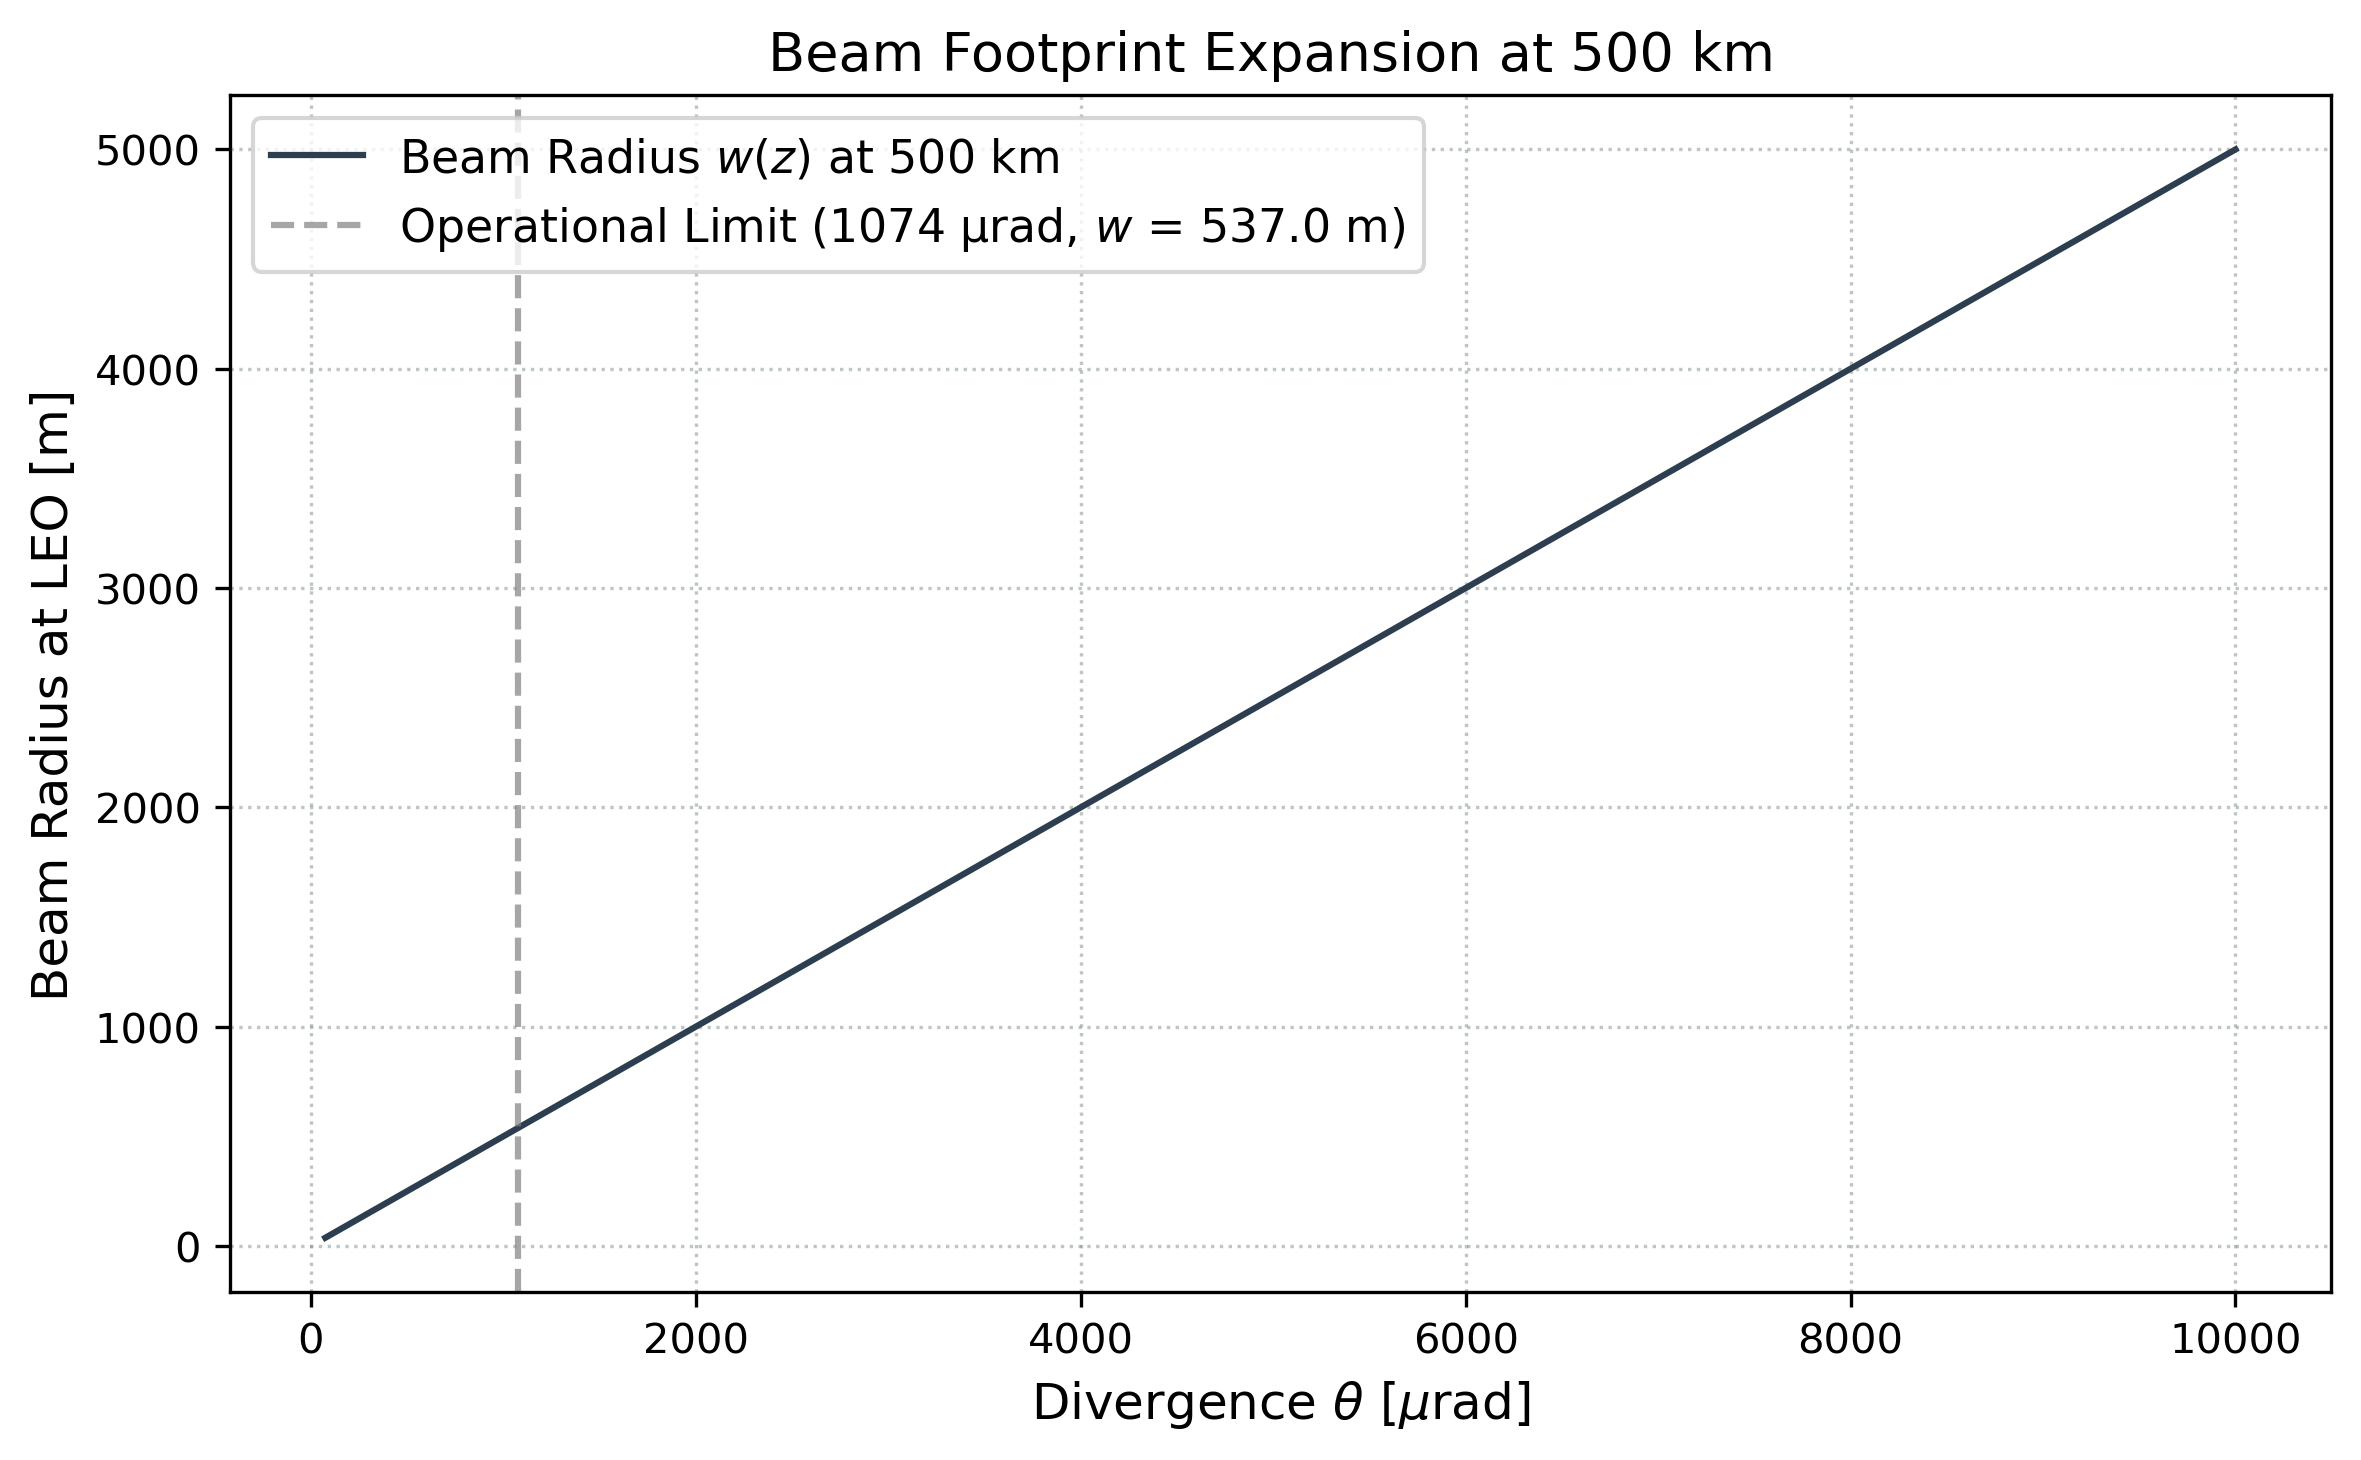

In [5]:
#div vs größe strahl bei leo 

#delta = np.linspace(-1e-3, 1e-3, 1001) # Mechanical displacement [m]
#s = f + delta      # Object distance (fiber to lens) [m]

#s=f #delta=0, perfect kollimiert

divergence_microrad = np.linspace(75, 10000, 1000)
divergence_rad = divergence_microrad * 1e-6

# Taillengrösse as a function of divergence: theta = lambda_eff / (pi * w0) => w0 = lambda_eff / (pi * theta)
w0_new = lam_eff / (np.pi * divergence_rad)

# Rayleigh-Länge des neuen Strahls
zR_neu = (np.pi * w0_new**2) / lam_eff

# Strahlradius bei z2 = 500 km
z2 = 500e3  # [m]
# Da z_waist näherungsweise an der Linse liegt (z_waist = 0), vereinfacht sich die Ausbreitung:
w_500km = w0_new * np.sqrt(1 + (z2 / zR_neu) ** 2)
target_div = 1074
w_at_1074 = np.interp(target_div, divergence_microrad, w_500km)

# ==========================================
# Plotting
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(
    divergence_microrad,
    w_500km,
    color="#2C3E50",
    label="Beam Radius $w(z)$ at 500 km",
)

# Visuelle Markierung deiner genutzten Obergrenze von 1000 µrad
ax.axvline(
    x=target_div,
    color="grey",
    linestyle="--",
    alpha=0.7,
    label=f"Operational Limit ({target_div} µrad, $w$ = {w_at_1074:.1f} m)",
)

ax.set_xlabel(r"Divergence $\theta$ [$\mu$rad]")
ax.set_ylabel("Beam Radius at LEO [m]")
ax.set_title("Beam Footprint Expansion at 500 km ")#(Assuming Perfect Collimation Baseline)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/calculations_for_prototype/range_divergence/beam_radius_leo.pdf")
plt.show()


